In [12]:
import pandas as pd
import numpy as np
from collections import defaultdict

In [ ]:
cancertypebatching_exp_0_warmup_0
cancertypebatching_exp_1_warmup_10



In [13]:
all_results = defaultdict(list)

In [ ]:
for gen_image in ['genetics_and_image', 'only_genetics', "only_image"]:
    for batch in ['ct_batch']:
        for exp in ['cancertypebatching_exp_0_warmup_0', 'cancertypebatching_exp_1_warmup_10']:
            path = f"/n/data2/hms/dbmi/kyu/lab/chb3333/gem-patho/models/actual_final_results/{gen_image}/{batch}/{exp}/global_test_cindices.csv"
            # path = f"/n/data2/hms/dbmi/kyu/lab/chb3333/gem-patho/models/actual_final_results/only_genetics/{batch}/cancertypebatching_exp_0_warmup_0/global_test_cindices.csv"

            data = pd.read_csv(path)
            print(data)

            for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
                all_results['gen_image'].append(gen_image)
                all_results['batch'].append(batch)
                all_results['exp'].append(exp)
                all_results['cancer'].append(cancer)
                all_results['c_index'].append(c_idx)

    cancer_type   c_index
0             8  0.516489
1             2  0.527678
2            10  0.511914
3            12  0.603139
4            11  0.515542
5            17  0.552211
6            15  0.466110
7            13  0.499172
8            20  0.502547
9            19  0.487710
10            6  0.486984
11            7  0.646809
12            3  0.522102
13            4  0.498328
14            1  0.481579
15            0  0.519116
16           21  0.487984
17           18  0.492615
18           35  0.473033
19           36  0.468442
20           14  0.457983
21           26  0.581748
22           28  0.432353
23           27  0.660062
24           23  0.489640
25           33  0.384746
26           25  0.497436
27           32  0.639679
28           30  0.503463
29           31  0.687683
30           24  0.554710
31           29  0.501020
32           34  0.596316
    cancer_type   c_index
0             8  0.516489
1             2  0.527678
2            10  0.511914
3           

In [19]:
df = pd.DataFrame(all_results)

data.to_csv("./test_df.csv")

In [20]:
data

,gen_image,batch,exp,cancer,c_index
0,genetics_and_image,ct_batch,cancertypebatching_exp_0_warmup_0,8,0.516489
1,genetics_and_image,ct_batch,cancertypebatching_exp_0_warmup_0,2,0.527678
2,genetics_and_image,ct_batch,cancertypebatching_exp_0_warmup_0,10,0.511914
3,genetics_and_image,ct_batch,cancertypebatching_exp_0_warmup_0,12,0.603139
4,genetics_and_image,ct_batch,cancertypebatching_exp_0_warmup_0,11,0.515542
...,...,...,...,...,...
193,only_image,ct_batch,cancertypebatching_exp_1_warmup_10,30,0.503463
194,only_image,ct_batch,cancertypebatching_exp_1_warmup_10,31,0.687683
195,only_image,ct_batch,cancertypebatching_exp_1_warmup_10,24,0.554710
196,only_image,ct_batch,cancertypebatching_exp_1_warmup_10,29,0.501020


/tmp/ipykernel_21078/2726875683.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(


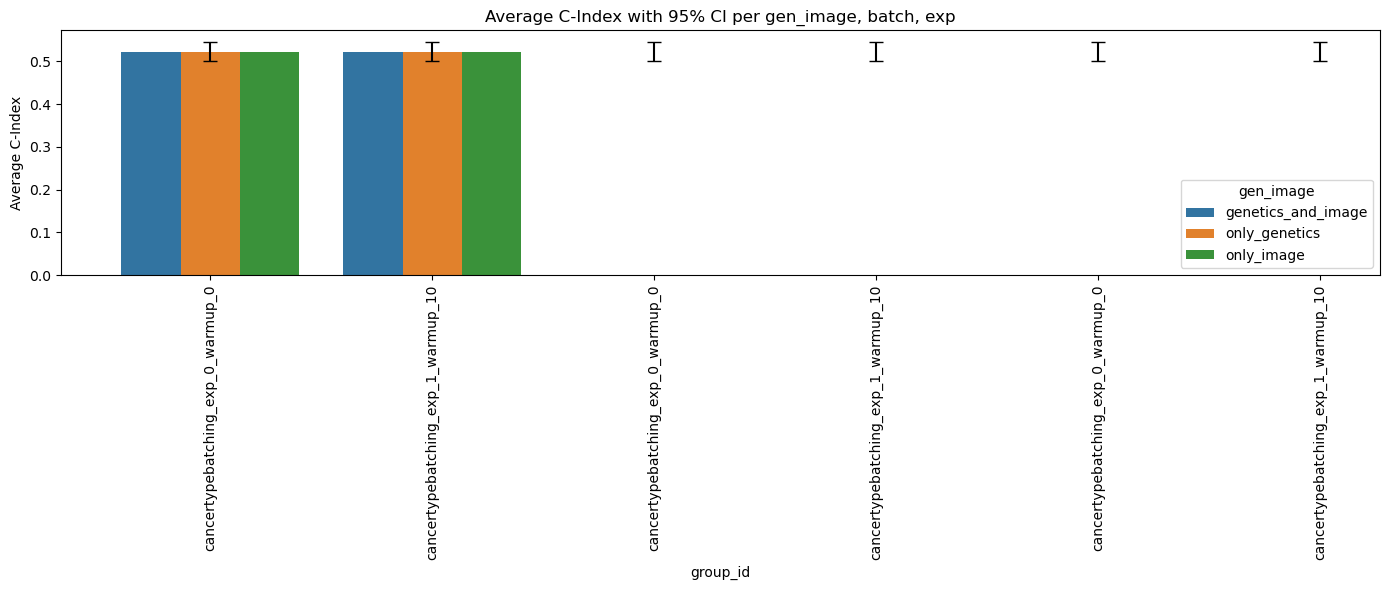

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Group by the required columns and compute the mean and standard error
grouped = df.groupby(['gen_image', 'batch', 'exp'])['c_index'].agg(['mean', 'sem']).reset_index()
grouped.rename(columns={'mean': 'avg_c_index', 'sem': 'se_c_index'}, inplace=True)
# Replot without the invalid 'errorbar' argument

# Create a unique identifier for each bar group to avoid position confusion
grouped['group_id'] = grouped.groupby(['gen_image', 'batch'])['exp'].transform(lambda x: pd.factorize(x)[0])

# Plot using seaborn with manual error bars
plt.figure(figsize=(14, 6))
barplot = sns.barplot(
    data=grouped,
    x='group_id', y='avg_c_index',
    hue='gen_image',
    ci=None,
    capsize=0.2
)

# Add error bars manually
for i, row in grouped.iterrows():
    barplot.errorbar(
        x=i,
        y=row['avg_c_index'],
        yerr=1.96 * row['se_c_index'],
        fmt='none',
        c='black',
        capsize=5
    )

# Tweak x-ticks to show 'exp' for clarity
barplot.set_xticks(range(len(grouped)))
barplot.set_xticklabels(grouped['exp'], rotation=90)
plt.ylabel('Average C-Index')
plt.title('Average C-Index with 95% CI per gen_image, batch, exp')
plt.tight_layout()
plt.show()



In [23]:
grouped

,gen_image,batch,exp,avg_c_index,se_c_index,group_id
0,genetics_and_image,ct_batch,cancertypebatching_exp_0_warmup_0,0.522616,0.011641,0
1,genetics_and_image,ct_batch,cancertypebatching_exp_1_warmup_10,0.522616,0.011641,1
2,only_genetics,ct_batch,cancertypebatching_exp_0_warmup_0,0.522616,0.011641,0
3,only_genetics,ct_batch,cancertypebatching_exp_1_warmup_10,0.522616,0.011641,1
4,only_image,ct_batch,cancertypebatching_exp_0_warmup_0,0.522616,0.011641,0
5,only_image,ct_batch,cancertypebatching_exp_1_warmup_10,0.522616,0.011641,1


In [25]:
# Group by the required columns and compute the mean and standard error
grouped = df.groupby(['gen_image', 'batch', 'exp'])['c_index'].agg(['mean', 'sem']).reset_index()
grouped.rename(columns={'mean': 'avg_c_index', 'sem': 'se_c_index'}, inplace=True)
# Replot without the invalid 'errorbar' argument
grouped

,gen_image,batch,exp,avg_c_index,se_c_index
0,genetics_and_image,ct_batch,cancertypebatching_exp_0_warmup_0,0.522616,0.011641
1,genetics_and_image,ct_batch,cancertypebatching_exp_1_warmup_10,0.522616,0.011641
2,only_genetics,ct_batch,cancertypebatching_exp_0_warmup_0,0.522616,0.011641
3,only_genetics,ct_batch,cancertypebatching_exp_1_warmup_10,0.522616,0.011641
4,only_image,ct_batch,cancertypebatching_exp_0_warmup_0,0.522616,0.011641
5,only_image,ct_batch,cancertypebatching_exp_1_warmup_10,0.522616,0.011641
